In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from google.cloud import bigquery

PROJECT_ID = "nyc-taxi-analytics-1"

client = bigquery.Client(project=PROJECT_ID)

def run_query(query: str) -> pd.DataFrame:
    query_job = client.query(query)
    return query_job.result().to_dataframe()

In [3]:
query_daily = f"""
SELECT
    pickup_date,
    pickup_year_month,
    day_of_week,
    day_name,
    is_weekend,
    total_trips,
    total_revenue,
    previous_day_trips,
    daily_trip_growth_percentage,
    demand_7_day_moving_avg
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_daily_demand`
ORDER BY pickup_date
"""

df_daily = run_query(query_daily)

df_daily["pickup_date"] = pd.to_datetime(df_daily["pickup_date"])

df_daily.head()

,pickup_date,pickup_year_month,day_of_week,day_name,is_weekend,total_trips,total_revenue,previous_day_trips,daily_trip_growth_percentage,demand_7_day_moving_avg
0,2023-01-01,2023-01,1,Sunday,True,69676,2144568.32,<NA>,NaN,69676.00
1,2023-01-02,2023-01,2,Monday,False,61538,1933294.95,69676,-11.68,65607.00
2,2023-01-03,2023-01,3,Tuesday,False,80011,2351261.88,61538,30.02,70408.33
3,2023-01-04,2023-01,4,Wednesday,False,88914,2502022.30,80011,11.13,75034.75
4,2023-01-05,2023-01,5,Thursday,False,94585,2585233.30,88914,6.38,78944.80


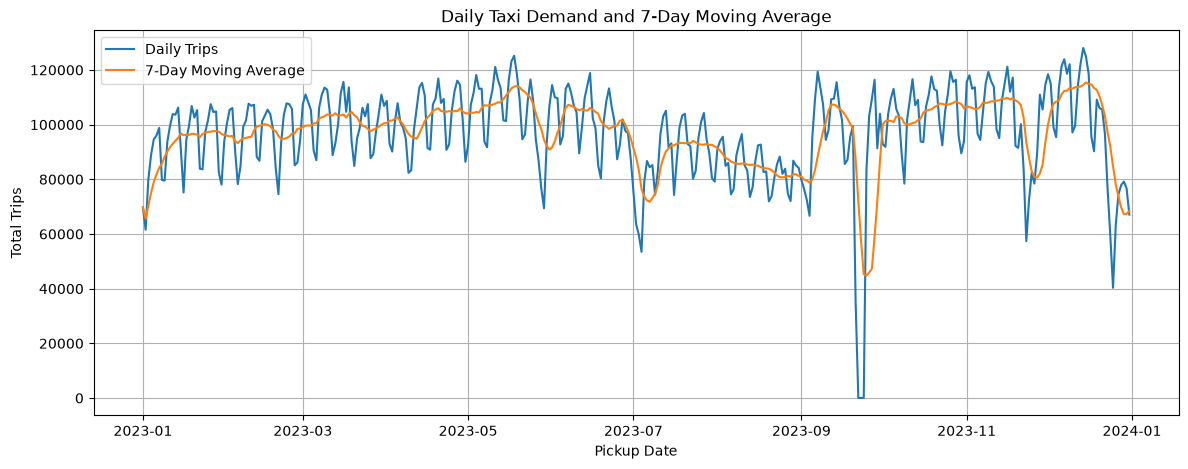

In [4]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_daily["pickup_date"],
    df_daily["total_trips"],
    label="Daily Trips"
)

plt.plot(
    df_daily["pickup_date"],
    df_daily["demand_7_day_moving_avg"],
    label="7-Day Moving Average"
)

plt.title("Daily Taxi Demand and 7-Day Moving Average")
plt.xlabel("Pickup Date")
plt.ylabel("Total Trips")
plt.legend()
plt.grid(True)
plt.show()

In [5]:
query_day_of_week = f"""
SELECT
    day_of_week,
    day_name,
    is_weekend,
    total_calendar_days,
    total_trips,
    avg_trips_per_day,
    total_revenue,
    avg_revenue_per_day,
    demand_rank,
    trip_share_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_day_of_week_demand`
ORDER BY day_of_week
"""

df_day_of_week = run_query(query_day_of_week)

df_day_of_week

,day_of_week,day_name,is_weekend,total_calendar_days,total_trips,avg_trips_per_day,total_revenue,avg_revenue_per_day,demand_rank,trip_share_percentage
0,1,Sunday,True,53,4444175,83852.36,1.313777e+08,2478824.46,7,12.57
1,2,Monday,False,52,4408713,84782.94,1.324223e+08,2546583.08,6,12.47
2,3,Tuesday,False,52,5133147,98714.37,1.482065e+08,2850124.38,5,14.52
3,4,Wednesday,False,52,5435874,104536.04,1.568722e+08,3016773.91,2,15.37
4,5,Thursday,False,52,5548341,106698.87,1.619095e+08,3113643.88,1,15.69
5,6,Friday,False,52,5241548,100799.00,1.511725e+08,2907163.33,3,14.82
6,7,Saturday,True,52,5147509,98990.56,1.389755e+08,2672606.19,4,14.56


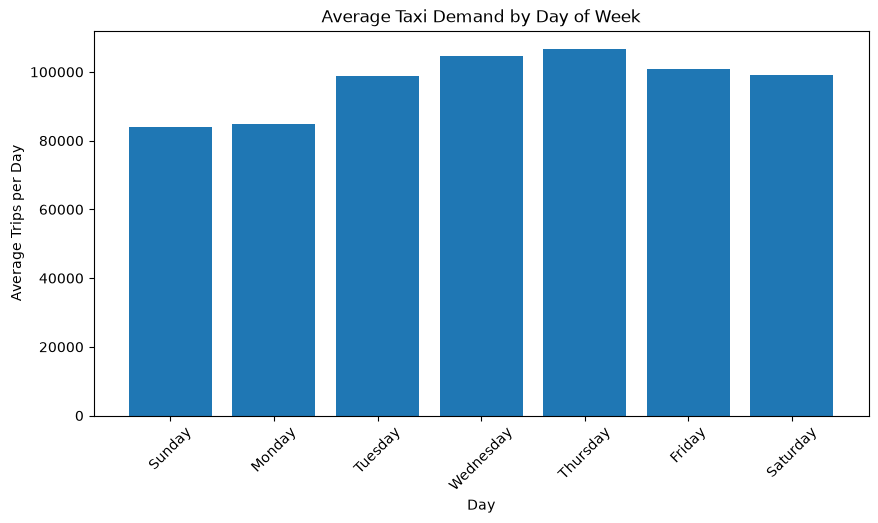

In [6]:
plt.figure(figsize=(10, 5))

plt.bar(
    df_day_of_week["day_name"],
    df_day_of_week["avg_trips_per_day"]
)

plt.title("Average Taxi Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Trips per Day")
plt.xticks(rotation=45)
plt.show()

In [7]:
query_hourly = f"""
SELECT
    pickup_hour,
    pickup_time_period,
    total_trips,
    active_days,
    avg_trips_per_active_day,
    total_revenue,
    avg_revenue_per_trip,
    demand_rank,
    revenue_rank,
    trip_share_percentage
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_hourly_demand`
ORDER BY pickup_hour
"""

df_hourly = run_query(query_hourly)

df_hourly.head()

,pickup_hour,pickup_time_period,total_trips,active_days,avg_trips_per_active_day,total_revenue,avg_revenue_per_trip,demand_rank,revenue_rank,trip_share_percentage
0,0,Late night,993738,364,2730.05,29104583.22,29.29,17,17,2.81
1,1,Late night,664396,363,1830.29,17739452.95,26.70,19,19,1.88
2,2,Late night,435923,362,1204.21,10986456.87,25.20,21,21,1.23
3,3,Late night,282756,362,781.09,7461934.98,26.39,22,22,0.80
4,4,Late night,176685,362,488.08,5936501.38,33.60,24,24,0.50


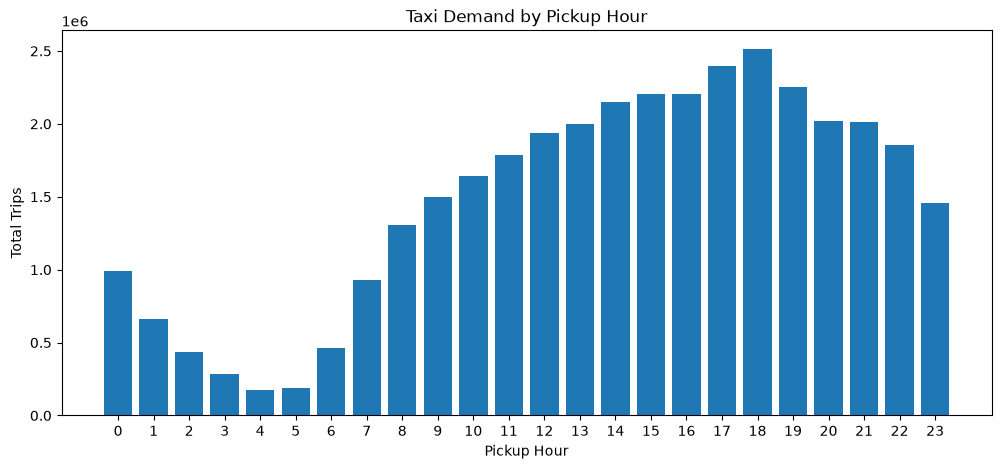

In [8]:
plt.figure(figsize=(12, 5))

plt.bar(
    df_hourly["pickup_hour"],
    df_hourly["total_trips"]
)

plt.title("Taxi Demand by Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Total Trips")
plt.xticks(range(0, 24))
plt.show()

In [14]:
query_heatmap = f"""
SELECT
    day_of_week,
    day_name,
    is_weekend,
    pickup_hour,
    total_trips,
    avg_trip_per_day,
    demand_rank
FROM `{PROJECT_ID}.nyc_taxi_dbt_reporting.rpt_demand_heatmap`
ORDER BY day_of_week, pickup_hour
"""

df_heatmap = run_query(query_heatmap)
df_heatmap.head()

,day_of_week,day_name,is_weekend,pickup_hour,total_trips,avg_trip_per_day,demand_rank
0,1,Sunday,True,0,252907,4771.83,84
1,1,Sunday,True,1,212675,4012.74,101
2,1,Sunday,True,2,153630,2898.68,116
3,1,Sunday,True,3,105547,1991.45,124
4,1,Sunday,True,4,56369,1063.57,139


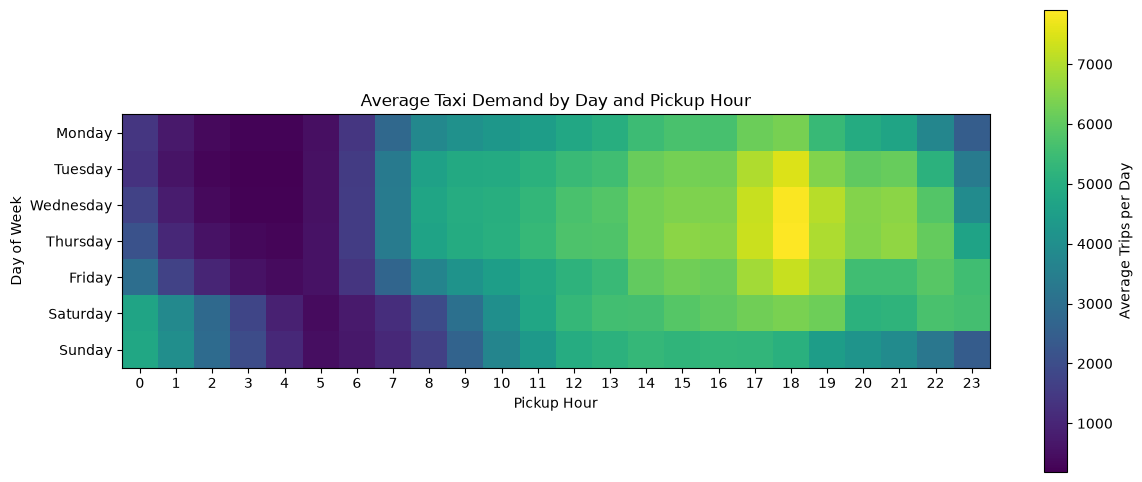

In [15]:
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

heatmap_data = (
    df_heatmap
    .pivot(
        index="day_name",
        columns="pickup_hour",
        values="avg_trip_per_day"
    )
    .reindex(day_order)
)

plt.figure(figsize=(14, 6))

plt.imshow(heatmap_data)

plt.title("Average Taxi Demand by Day and Pickup Hour")
plt.xlabel("Pickup Hour")
plt.ylabel("Day of Week")

plt.xticks(
    ticks=range(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=range(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.colorbar(label="Average Trips per Day")
plt.show()